# Análise Exploratória — Dataset de Treino

Análise completa dos dados de treino (`training.csv`) cruzados com o catálogo de filmes (`cbf_df.csv`).  
Objetivos:
- Entender a distribuição de ratings e comportamento dos usuários
- Identificar tendências de gênero por perfil de usuário
- Levantar a distribuição de gêneros do catálogo de filmes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

TRAINING_PATH = 'data_spliting/training.csv'
CBF_PATH      = 'data/cbf_df.csv'

## 1. Carregamento e merge dos dados

In [2]:
train = pd.read_csv(TRAINING_PATH)
cbf   = pd.read_csv(CBF_PATH, usecols=['movie_id', 'title', 'genres', 'year',
                                        'tmdb_rating', 'imdb_rating', 'director'])

print(f'Training  : {train.shape[0]:,} linhas, {train.shape[1]} colunas')
print(f'CBF catálogo: {cbf.shape[0]:,} linhas')
train.head(3)

Training  : 38,614 linhas, 4 colunas
CBF catálogo: 9,708 linhas


,userId,movieId,rating,timestamp
0,1,3,4.0,964981247
1,1,6,4.0,964982224
2,1,47,5.0,964983815


In [3]:
# Merge training com metadados de filmes
df = train.merge(cbf, left_on='movieId', right_on='movie_id', how='left')

# Explodir gêneros (pipe-separated) em linhas individuais
df_genres = df.dropna(subset=['genres']).copy()
df_genres = df_genres.assign(genre=df_genres['genres'].str.split('|')).explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

print(f'Linhas após explode de gêneros: {df_genres.shape[0]:,}')
print(f'Gêneros únicos: {df_genres["genre"].nunique()}')
df_genres[['userId','movieId','rating','title','genre']].head(5)

Linhas após explode de gêneros: 105,627
Gêneros únicos: 19


,userId,movieId,rating,title,genre
0,1,3,4.0,Grumpier Old Men (1995),Comedy
0,1,3,4.0,Grumpier Old Men (1995),Romance
1,1,6,4.0,Heat (1995),Action
1,1,6,4.0,Heat (1995),Crime
1,1,6,4.0,Heat (1995),Thriller


---
## 2. Visão geral dos ratings

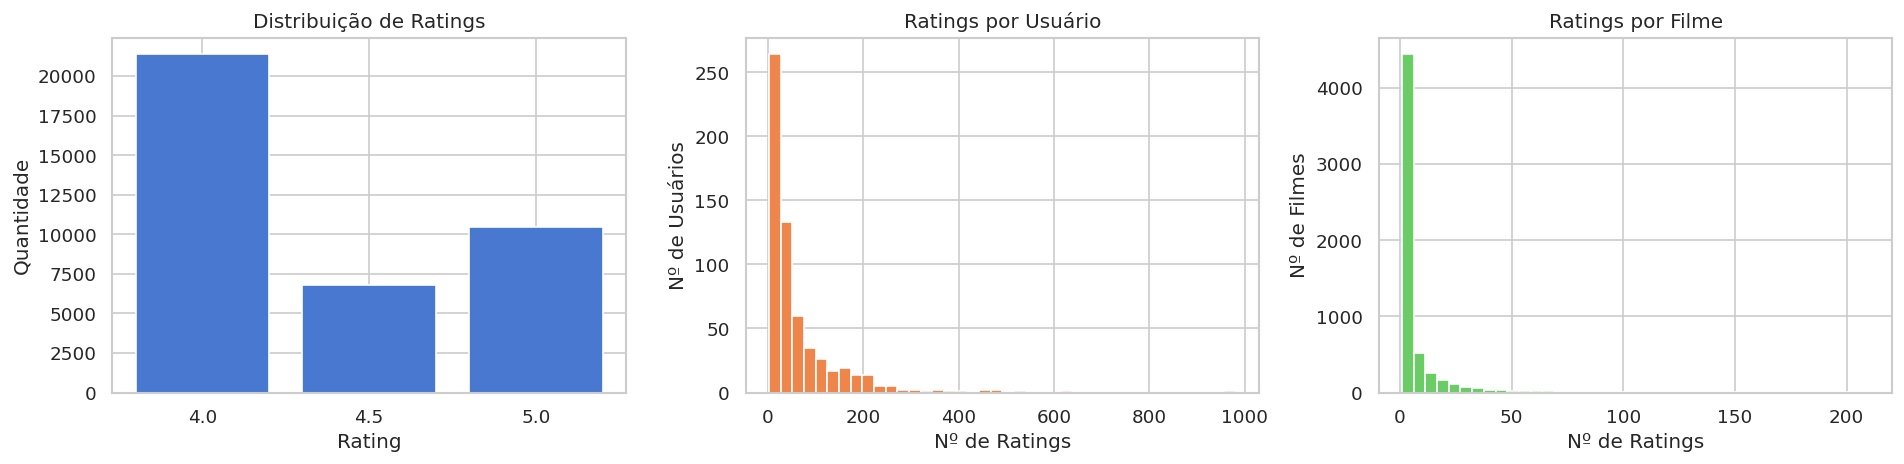

Usuários únicos : 608
Filmes únicos   : 5,775
Rating médio    : 4.36
Rating mediano  : 4.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2.1 Distribuição de ratings
rating_counts = train['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=sns.color_palette('muted')[0])
axes[0].set_title('Distribuição de Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')

# 2.2 Ratings por usuário (histograma)
ratings_per_user = train.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=40, color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_title('Ratings por Usuário')
axes[1].set_xlabel('Nº de Ratings')
axes[1].set_ylabel('Nº de Usuários')

# 2.3 Filmes avaliados (histograma)
ratings_per_movie = train.groupby('movieId')['rating'].count()
axes[2].hist(ratings_per_movie, bins=40, color=sns.color_palette('muted')[2], edgecolor='white')
axes[2].set_title('Ratings por Filme')
axes[2].set_xlabel('Nº de Ratings')
axes[2].set_ylabel('Nº de Filmes')

plt.tight_layout()
plt.show()

print(f"Usuários únicos : {train['userId'].nunique():,}")
print(f"Filmes únicos   : {train['movieId'].nunique():,}")
print(f"Rating médio    : {train['rating'].mean():.2f}")
print(f"Rating mediano  : {train['rating'].median():.1f}")

---
## 3. Análise de Gêneros — Catálogo de Filmes

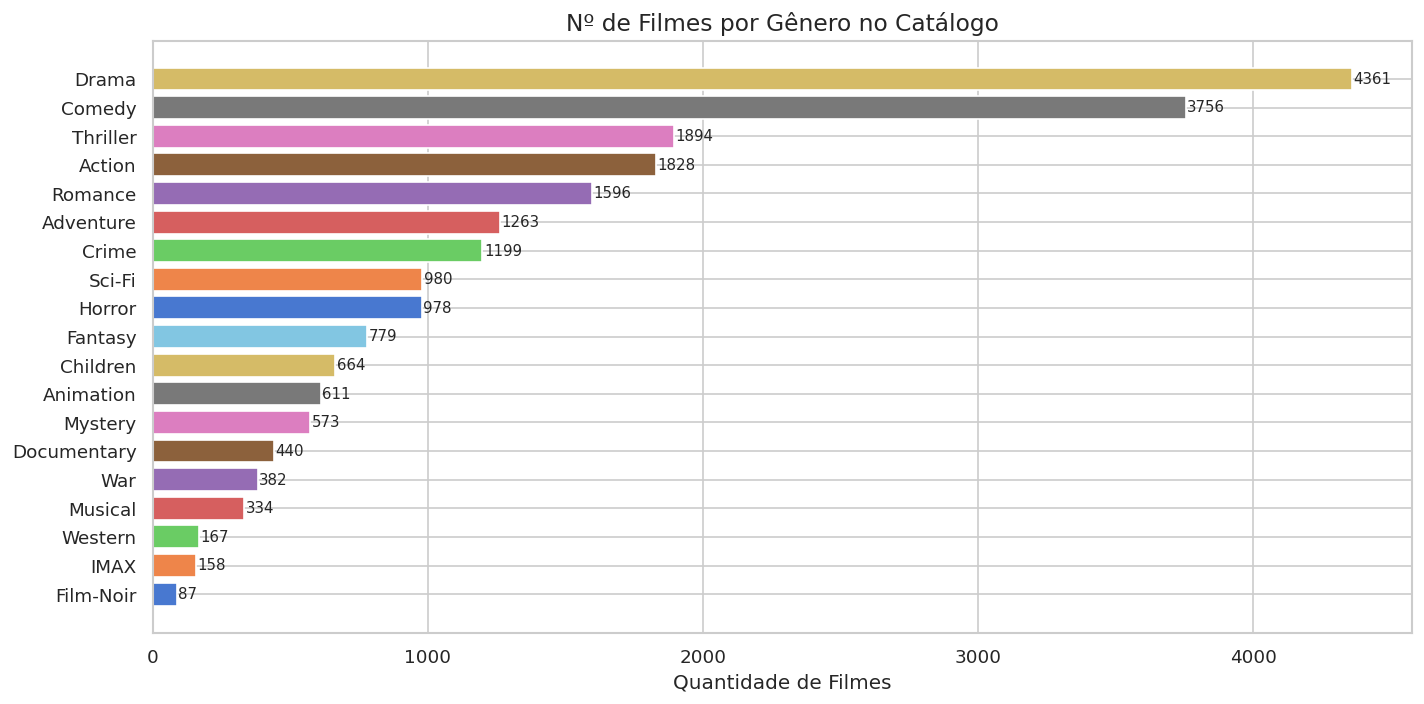

In [5]:
# 3.1 Gêneros únicos do catálogo (sem duplicar filmes)
cbf_genres = cbf.dropna(subset=['genres']).copy()
cbf_genres = cbf_genres.assign(genre=cbf_genres['genres'].str.split('|')).explode('genre')
cbf_genres['genre'] = cbf_genres['genre'].str.strip()

genre_movie_count = cbf_genres.groupby('genre')['movie_id'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_movie_count.index[::-1], genre_movie_count.values[::-1],
               color=sns.color_palette('muted', len(genre_movie_count)))
ax.set_title('Nº de Filmes por Gênero no Catálogo', fontsize=14)
ax.set_xlabel('Quantidade de Filmes')
for bar, val in zip(bars, genre_movie_count.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

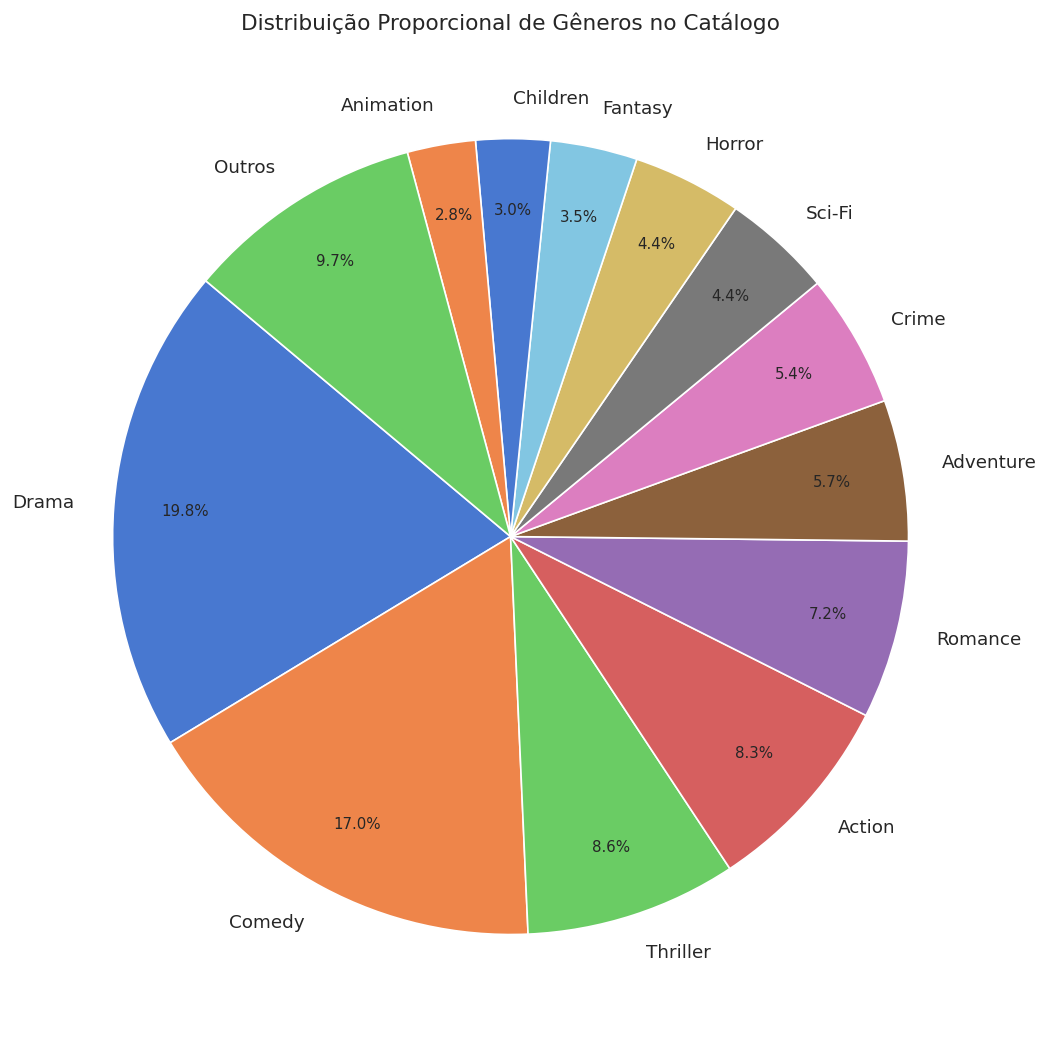

In [6]:
# 3.2 Proporção de gêneros — Pizza
top_genres = genre_movie_count.head(12)
outros = genre_movie_count.iloc[12:].sum()
pie_data = pd.concat([top_genres, pd.Series({'Outros': outros})])

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    pie_data.values, labels=pie_data.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('muted', len(pie_data)),
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Distribuição Proporcional de Gêneros no Catálogo', fontsize=13)
plt.tight_layout()
plt.show()

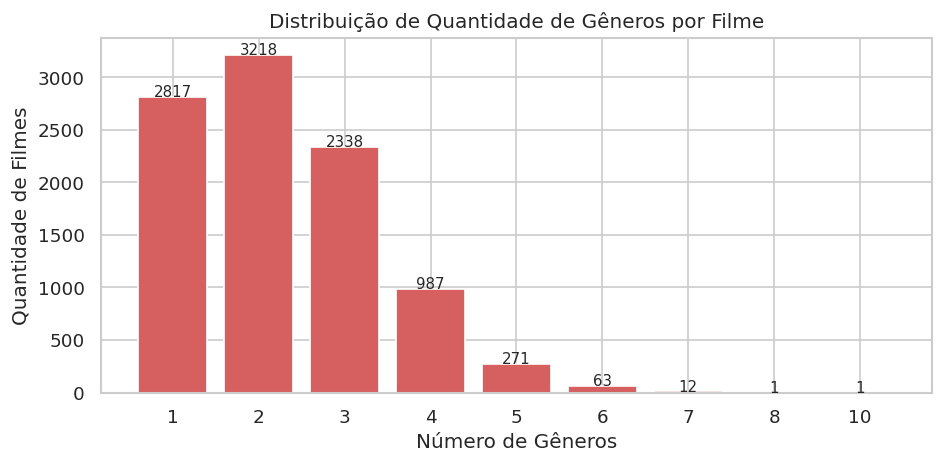

In [7]:
# 3.3 Filmes com múltiplos gêneros
cbf['n_genres'] = cbf['genres'].dropna().apply(lambda x: len(x.split('|')))
genre_dist = cbf['n_genres'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(genre_dist.index.astype(str), genre_dist.values,
       color=sns.color_palette('muted')[3])
ax.set_title('Distribuição de Quantidade de Gêneros por Filme')
ax.set_xlabel('Número de Gêneros')
ax.set_ylabel('Quantidade de Filmes')
for i, v in enumerate(genre_dist.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Rating médio por Gênero

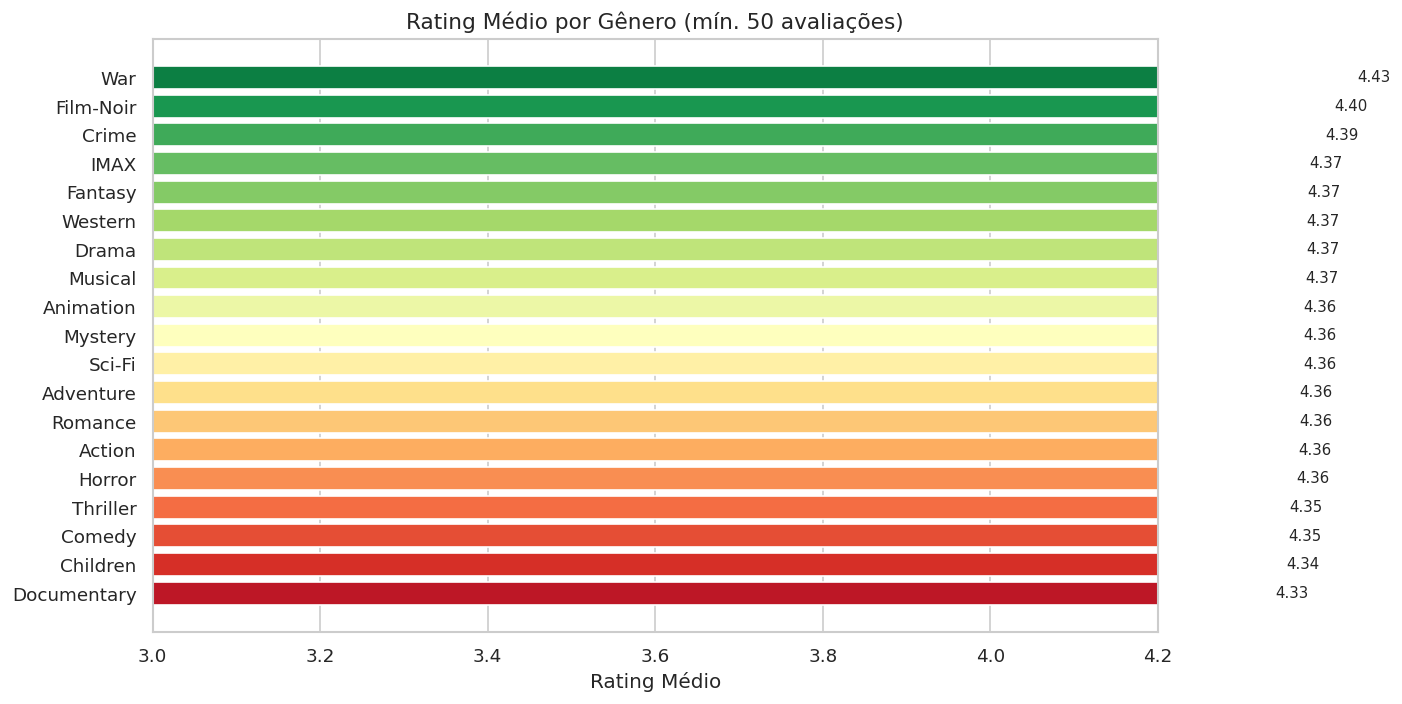

In [8]:
genre_rating = (
    df_genres.groupby('genre')
    .agg(avg_rating=('rating', 'mean'), n_ratings=('rating', 'count'))
    .query('n_ratings >= 50')
    .sort_values('avg_rating', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('RdYlGn', len(genre_rating))
bars = ax.barh(genre_rating.index[::-1], genre_rating['avg_rating'][::-1], color=palette)
ax.set_xlim(3.0, 4.2)
ax.set_title('Rating Médio por Gênero (mín. 50 avaliações)', fontsize=13)
ax.set_xlabel('Rating Médio')
for bar, val in zip(bars, genre_rating['avg_rating'][::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Perfis de Usuário — Tendências de Gênero

In [9]:
# Matriz usuário x gênero (contagem de interações)
user_genre_matrix = (
    df_genres.groupby(['userId', 'genre'])['rating']
    .count()
    .unstack(fill_value=0)
)

# Normalizar por usuário (proporção)
user_genre_norm = user_genre_matrix.div(user_genre_matrix.sum(axis=1), axis=0)

print(f'Matriz usuário × gênero: {user_genre_matrix.shape}')
user_genre_norm.head(3)

Matriz usuário × gênero: (608, 19)


genre,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,
1,0.130802,0.124473,0.042194,0.063291,0.113924,0.061181,0.000000,0.103376,0.069620,0.00211,0.018987,0.000000,0.031646,0.016878,0.042194,0.065401,0.071730,0.033755,0.008439
2,0.181818,0.060606,0.000000,0.000000,0.090909,0.090909,0.060606,0.242424,0.000000,0.00000,0.000000,0.030303,0.000000,0.030303,0.030303,0.030303,0.121212,0.030303,0.000000
3,0.212121,0.060606,0.000000,0.000000,0.030303,0.000000,0.000000,0.030303,0.030303,0.00000,0.212121,0.000000,0.000000,0.030303,0.000000,0.272727,0.121212,0.000000,0.000000


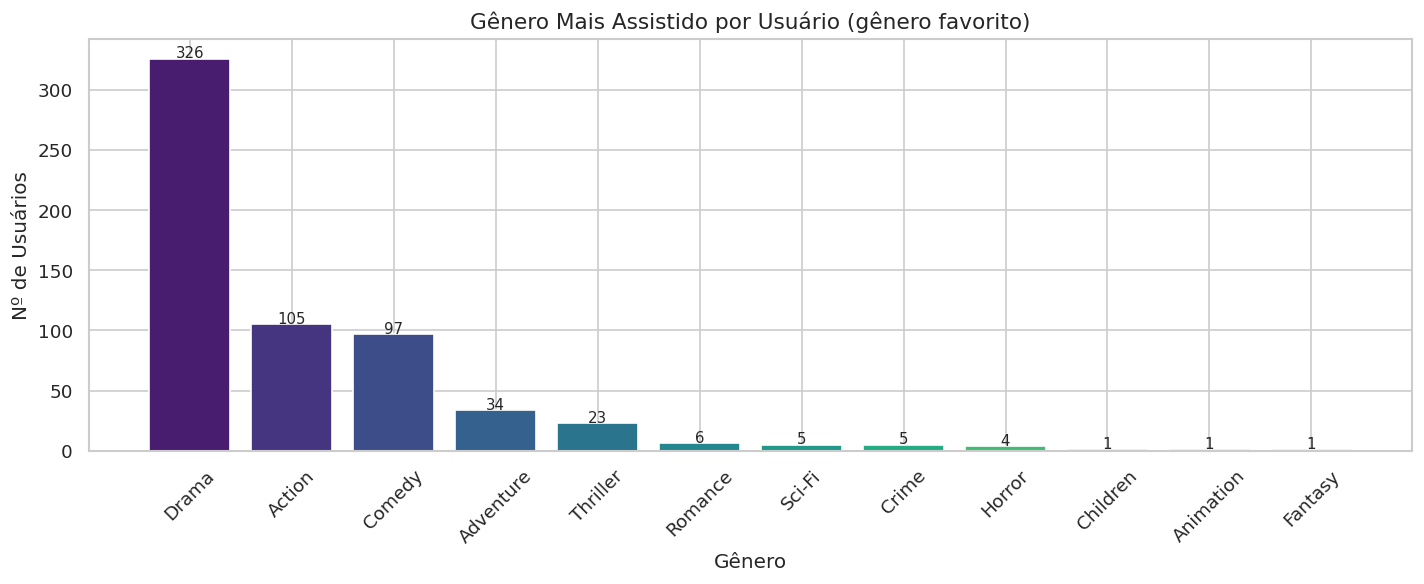

In [10]:
# 5.1 Gênero mais assistido por usuário
user_fav_genre = user_genre_matrix.idxmax(axis=1)
fav_genre_count = user_fav_genre.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(fav_genre_count.index, fav_genre_count.values,
              color=sns.color_palette('viridis', len(fav_genre_count)))
ax.set_title('Gênero Mais Assistido por Usuário (gênero favorito)', fontsize=13)
ax.set_xlabel('Gênero')
ax.set_ylabel('Nº de Usuários')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, fav_genre_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

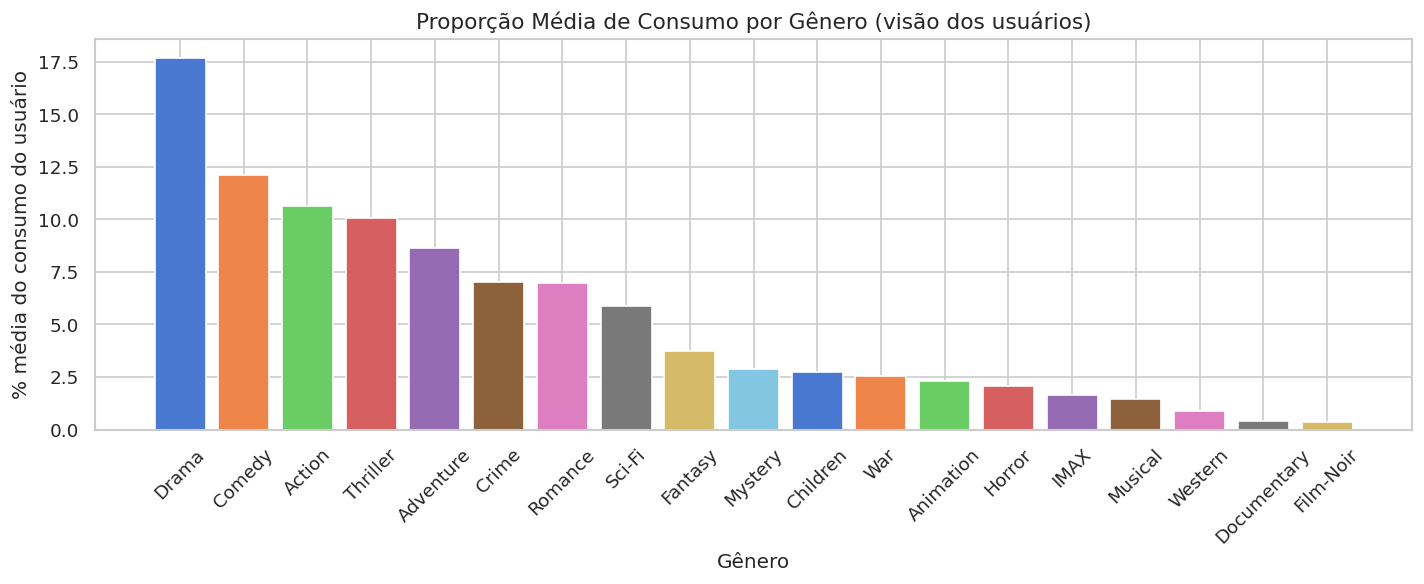

In [11]:
# 5.2 Proporção média de gênero consumida pelos usuários
mean_user_genre = user_genre_norm.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(mean_user_genre.index, mean_user_genre.values * 100,
       color=sns.color_palette('muted', len(mean_user_genre)))
ax.set_title('Proporção Média de Consumo por Gênero (visão dos usuários)', fontsize=13)
ax.set_xlabel('Gênero')
ax.set_ylabel('% média do consumo do usuário')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

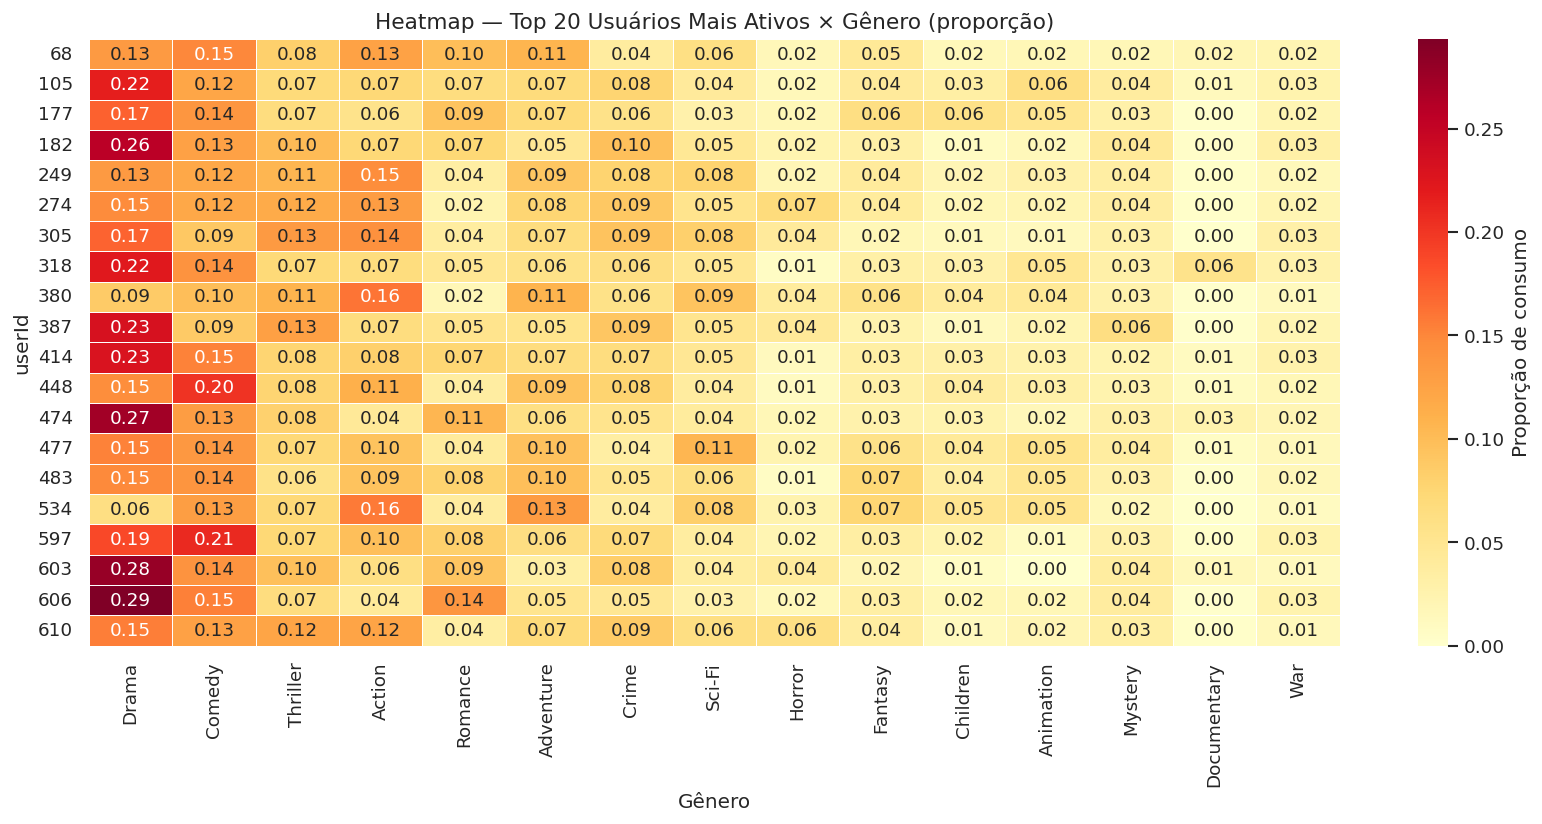

In [12]:
# 5.3 Heatmap — Top 20 usuários mais ativos × Gêneros
top_users = train.groupby('userId')['rating'].count().nlargest(20).index
heatmap_data = user_genre_norm.loc[user_genre_norm.index.isin(top_users)]

# Manter só gêneros principais
top_genre_cols = genre_movie_count.head(15).index.tolist()
heatmap_data = heatmap_data[[c for c in top_genre_cols if c in heatmap_data.columns]]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Proporção de consumo'}
)
ax.set_title('Heatmap — Top 20 Usuários Mais Ativos × Gênero (proporção)', fontsize=13)
ax.set_xlabel('Gênero')
ax.set_ylabel('userId')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5146/1655807.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Gênero', y='Proporção', palette='Set2', ax=ax)


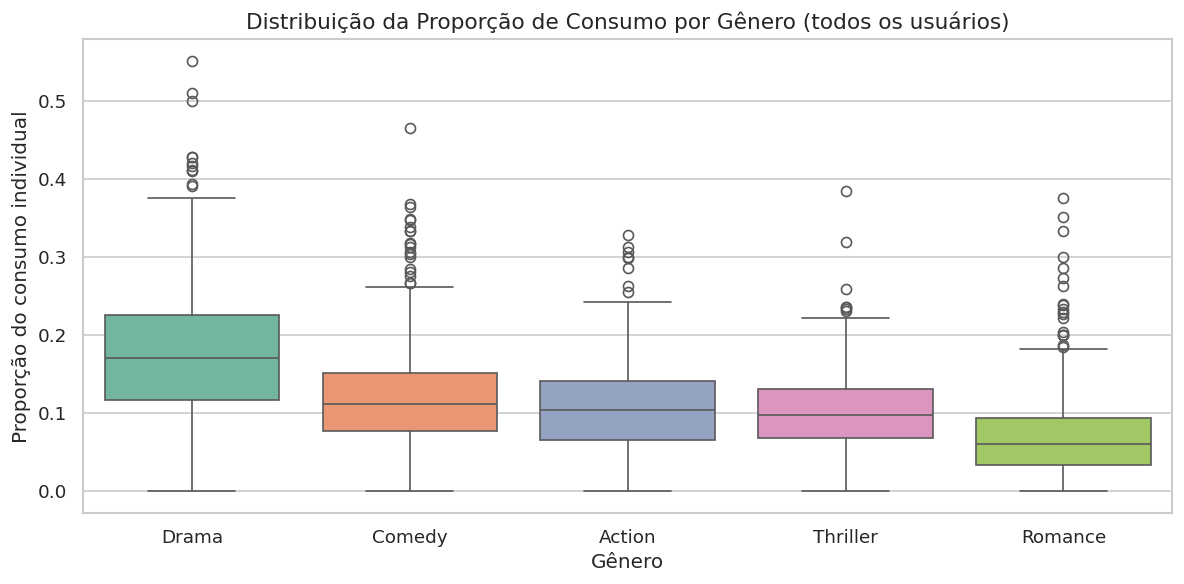

In [13]:
# 5.4 Boxplot — Distribuição da proporção de Drama e Comedy por usuário
genres_to_compare = ['Drama', 'Comedy', 'Action', 'Thriller', 'Romance']
genres_to_compare = [g for g in genres_to_compare if g in user_genre_norm.columns]

plot_df = user_genre_norm[genres_to_compare].melt(var_name='Gênero', value_name='Proporção')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x='Gênero', y='Proporção', palette='Set2', ax=ax)
ax.set_title('Distribuição da Proporção de Consumo por Gênero (todos os usuários)', fontsize=13)
ax.set_ylabel('Proporção do consumo individual')
plt.tight_layout()
plt.show()

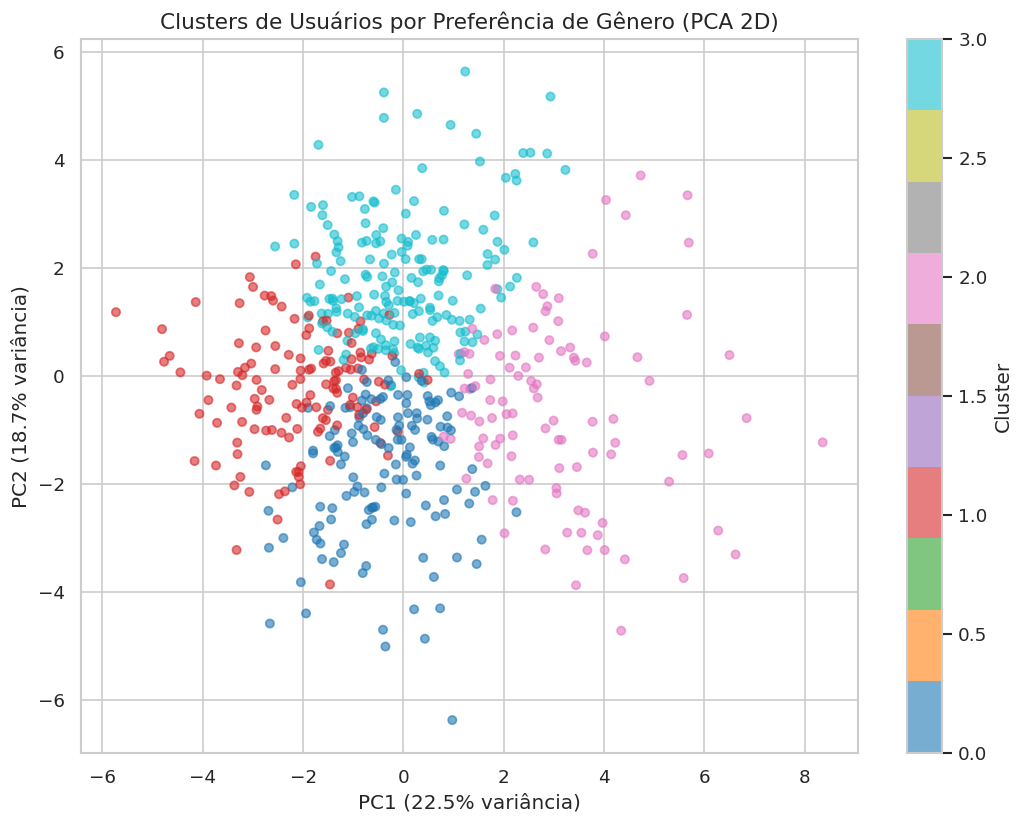


Variância explicada pelos 2 PCs: 41.1%


In [14]:
# 5.5 Cluster de usuários por gênero (K-Means simples, k=4)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Filtrar usuários com mínimo de avaliações
active_users = ratings_per_user[ratings_per_user >= 10].index
X = user_genre_norm.loc[user_genre_norm.index.isin(active_users)].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'],
                     cmap='tab10', alpha=0.6, s=25)
ax.set_title('Clusters de Usuários por Preferência de Gênero (PCA 2D)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

print(f'\nVariância explicada pelos 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

In [15]:
# 5.6 Perfil médio de cada cluster
X_df = X.copy()
X_df['cluster'] = clusters
cluster_profile = X_df.groupby('cluster').mean()

# Top 3 gêneros de cada cluster
print('=== Perfil dos Clusters (top 3 gêneros) ===')
for c in cluster_profile.index:
    top3 = cluster_profile.loc[c].sort_values(ascending=False).head(3)
    n_users = (X_df['cluster'] == c).sum()
    print(f'Cluster {c} ({n_users} usuários): ' + ', '.join([f"{g} ({v:.2%})" for g, v in top3.items()]))

=== Perfil dos Clusters (top 3 gêneros) ===
Cluster 0 (138 usuários): Drama (22.86%), Comedy (16.43%), Romance (11.96%)
Cluster 1 (130 usuários): Drama (22.74%), Thriller (13.06%), Crime (11.08%)
Cluster 2 (104 usuários): Comedy (13.78%), Drama (12.76%), Adventure (11.41%)
Cluster 3 (185 usuários): Action (16.12%), Drama (13.09%), Thriller (11.84%)


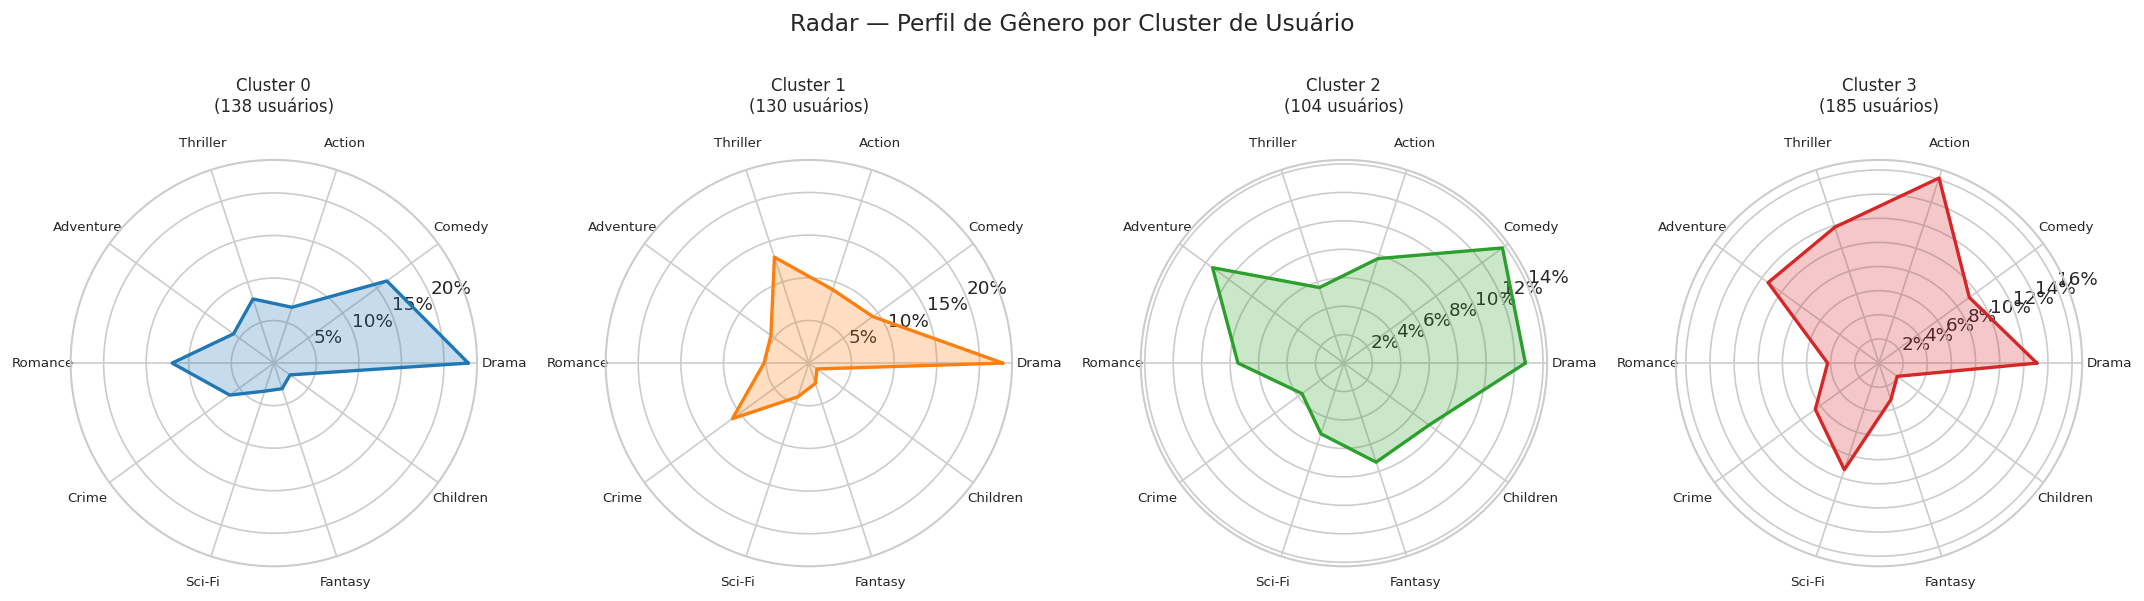

In [16]:
# 5.7 Radar chart — perfil de cada cluster
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib

top_genre_radar = cluster_profile.mean().sort_values(ascending=False).head(10).index.tolist()
cluster_radar = cluster_profile[top_genre_radar]

angles = np.linspace(0, 2 * np.pi, len(top_genre_radar), endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

fig, axes = plt.subplots(1, 4, figsize=(18, 5), subplot_kw=dict(polar=True))
colors = plt.cm.tab10.colors

for idx, (c, ax) in enumerate(zip(cluster_radar.index, axes)):
    values = cluster_radar.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2)
    ax.fill(angles, values, color=colors[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(top_genre_radar, size=8)
    n_users = (X_df['cluster'] == c).sum()
    ax.set_title(f'Cluster {c}\n({n_users} usuários)', size=10, pad=15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig.suptitle('Radar — Perfil de Gênero por Cluster de Usuário', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Rating médio por usuário — Distribuição

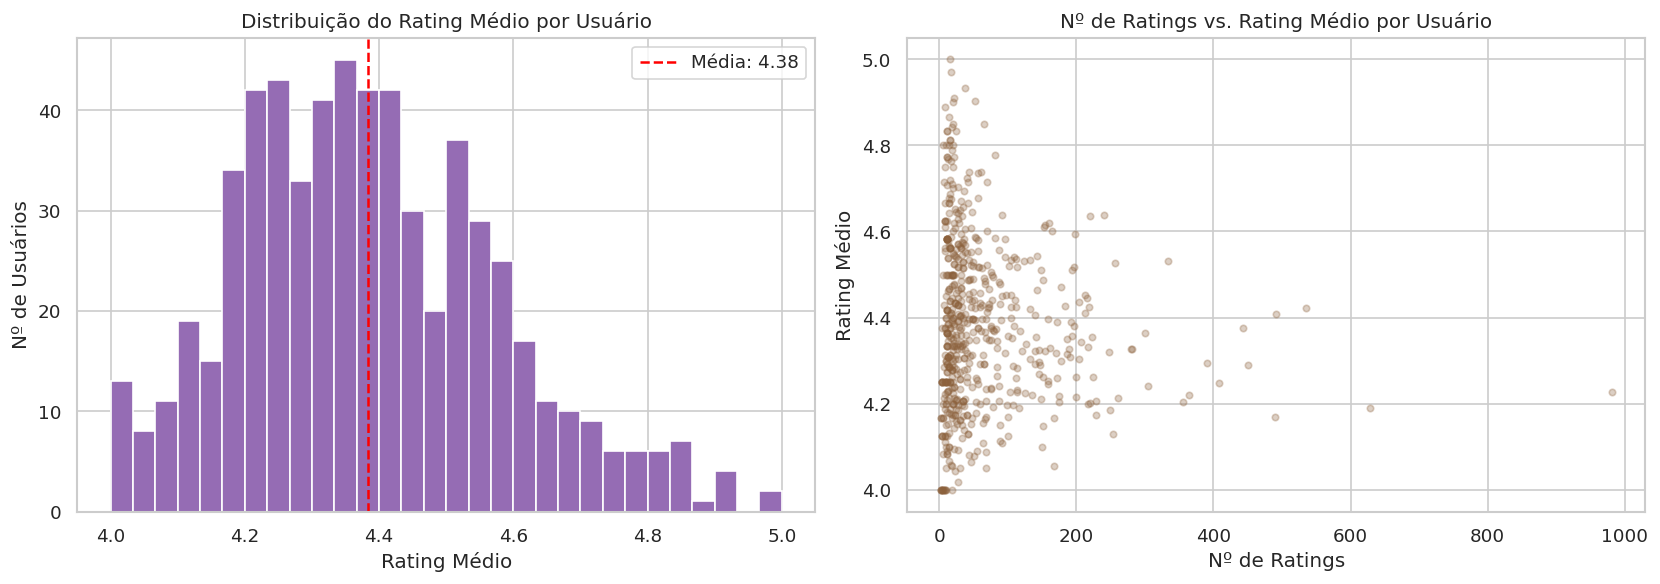

In [17]:
user_avg_rating = train.groupby('userId')['rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 Histograma do rating médio por usuário
axes[0].hist(user_avg_rating, bins=30, color=sns.color_palette('muted')[4], edgecolor='white')
axes[0].axvline(user_avg_rating.mean(), color='red', linestyle='--', label=f'Média: {user_avg_rating.mean():.2f}')
axes[0].set_title('Distribuição do Rating Médio por Usuário')
axes[0].set_xlabel('Rating Médio')
axes[0].set_ylabel('Nº de Usuários')
axes[0].legend()

# 6.2 Scatter — Nº de ratings vs rating médio
scatter_df = pd.DataFrame({'n_ratings': ratings_per_user, 'avg_rating': user_avg_rating})
axes[1].scatter(scatter_df['n_ratings'], scatter_df['avg_rating'],
                alpha=0.3, s=15, color=sns.color_palette('muted')[5])
axes[1].set_title('Nº de Ratings vs. Rating Médio por Usuário')
axes[1].set_xlabel('Nº de Ratings')
axes[1].set_ylabel('Rating Médio')

plt.tight_layout()
plt.show()

---
## 7. Evolução temporal dos ratings

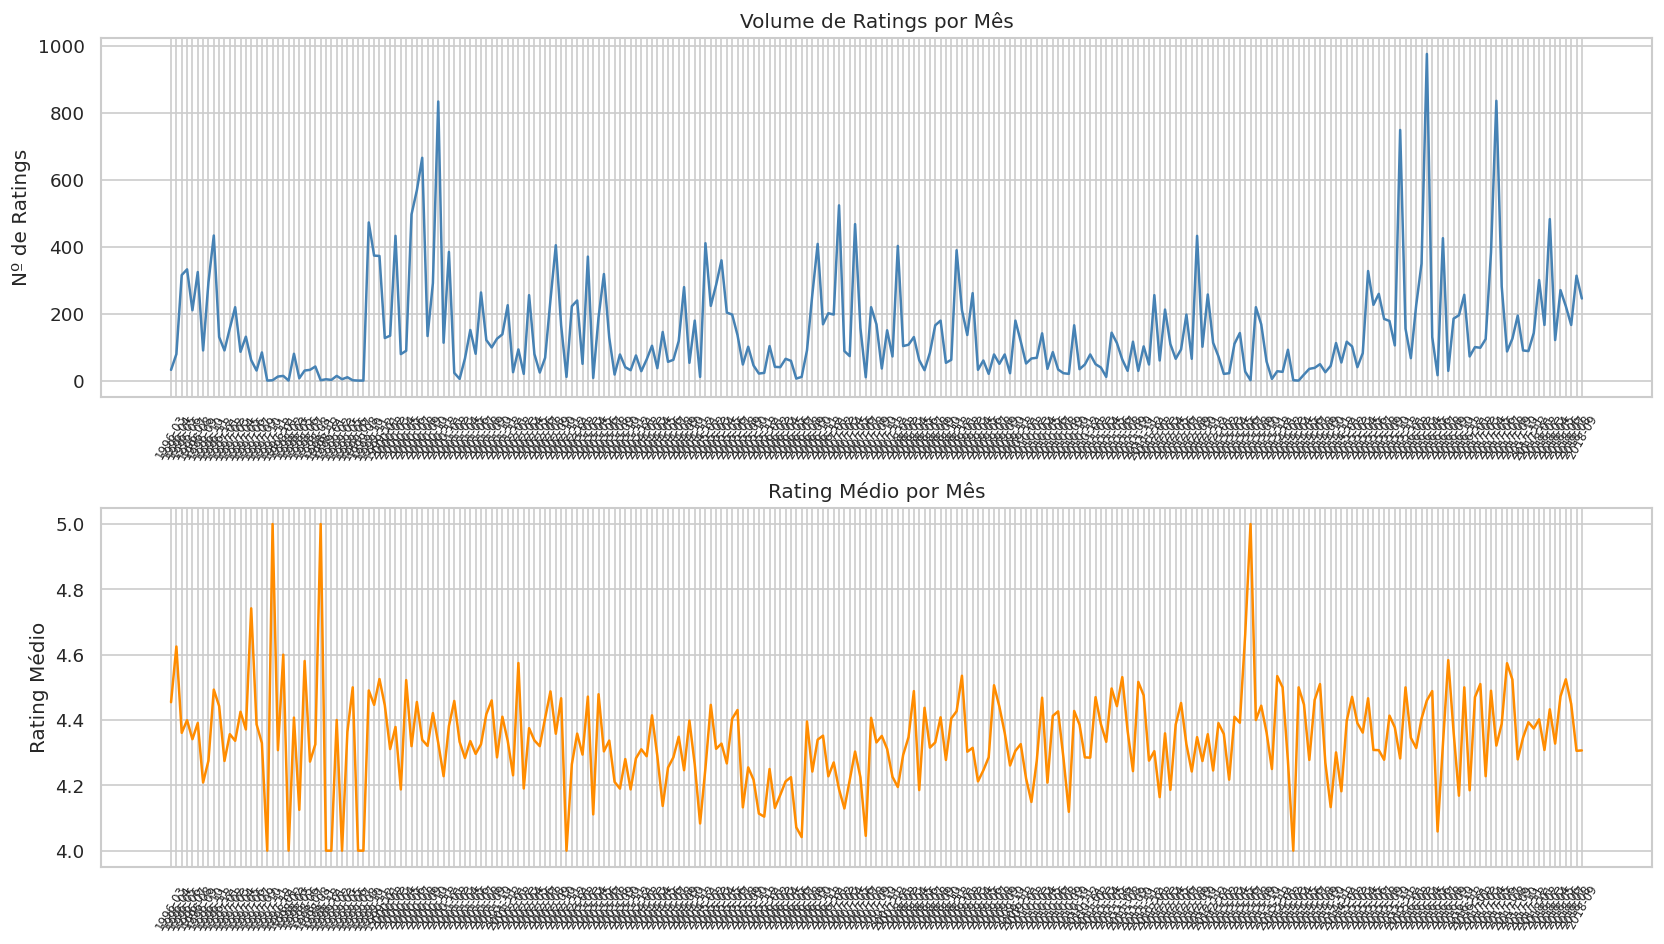

In [18]:
train['date'] = pd.to_datetime(train['timestamp'], unit='s')
train['year_month'] = train['date'].dt.to_period('M')

monthly = train.groupby('year_month').agg(
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(monthly['year_month_str'], monthly['n_ratings'], color='steelblue', lw=1.5)
axes[0].set_title('Volume de Ratings por Mês')
axes[0].set_ylabel('Nº de Ratings')
axes[0].tick_params(axis='x', rotation=60, labelsize=7)

axes[1].plot(monthly['year_month_str'], monthly['avg_rating'], color='darkorange', lw=1.5)
axes[1].set_title('Rating Médio por Mês')
axes[1].set_ylabel('Rating Médio')
axes[1].tick_params(axis='x', rotation=60, labelsize=7)

plt.tight_layout()
plt.show()

---
## 8. Top Filmes e Diretores

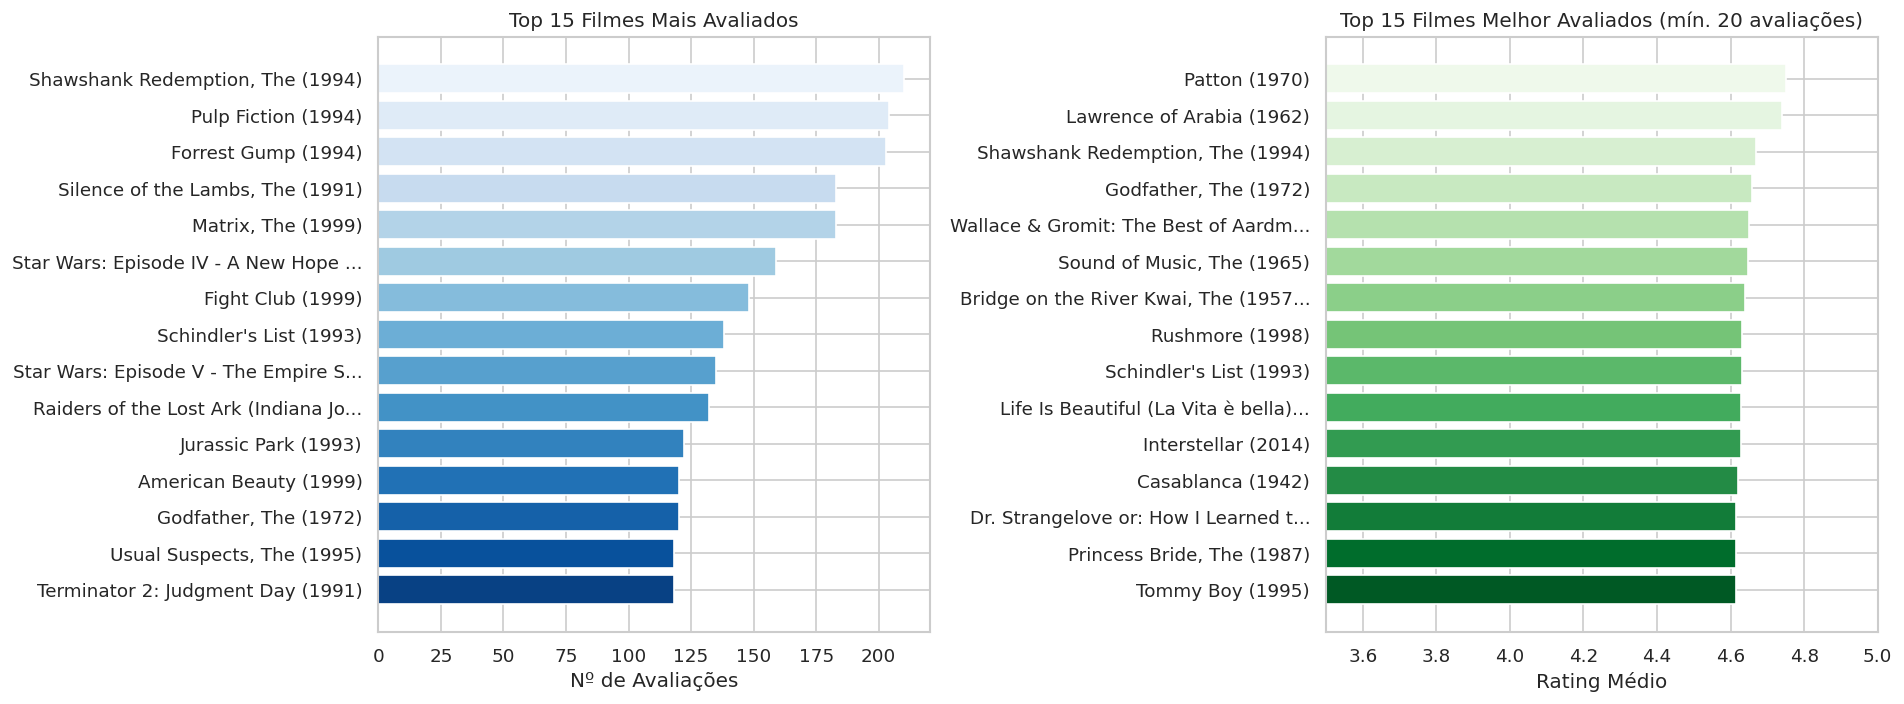

In [19]:
# 8.1 Filmes mais avaliados
top_movies = (
    df.dropna(subset=['title'])
    .groupby(['movieId', 'title'])
    .agg(n_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .reset_index()
    .query('n_ratings >= 20')
    .sort_values('n_ratings', ascending=False)
    .head(15)
)

top_rated = (
    df.dropna(subset=['title'])
    .groupby(['movieId', 'title'])
    .agg(n_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .reset_index()
    .query('n_ratings >= 20')
    .sort_values('avg_rating', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels  = [t[:35] + '...' if len(t) > 35 else t for t in top_movies['title']]
labels2 = [t[:35] + '...' if len(t) > 35 else t for t in top_rated['title']]

axes[0].barh(labels[::-1], top_movies['n_ratings'].values[::-1], color=sns.color_palette('Blues_r', 15))
axes[0].set_title('Top 15 Filmes Mais Avaliados')
axes[0].set_xlabel('Nº de Avaliações')

axes[1].barh(labels2[::-1], top_rated['avg_rating'].values[::-1], color=sns.color_palette('Greens_r', 15))
axes[1].set_title('Top 15 Filmes Melhor Avaliados (mín. 20 avaliações)')
axes[1].set_xlabel('Rating Médio')
axes[1].set_xlim(3.5, 5.0)

plt.tight_layout()
plt.show()

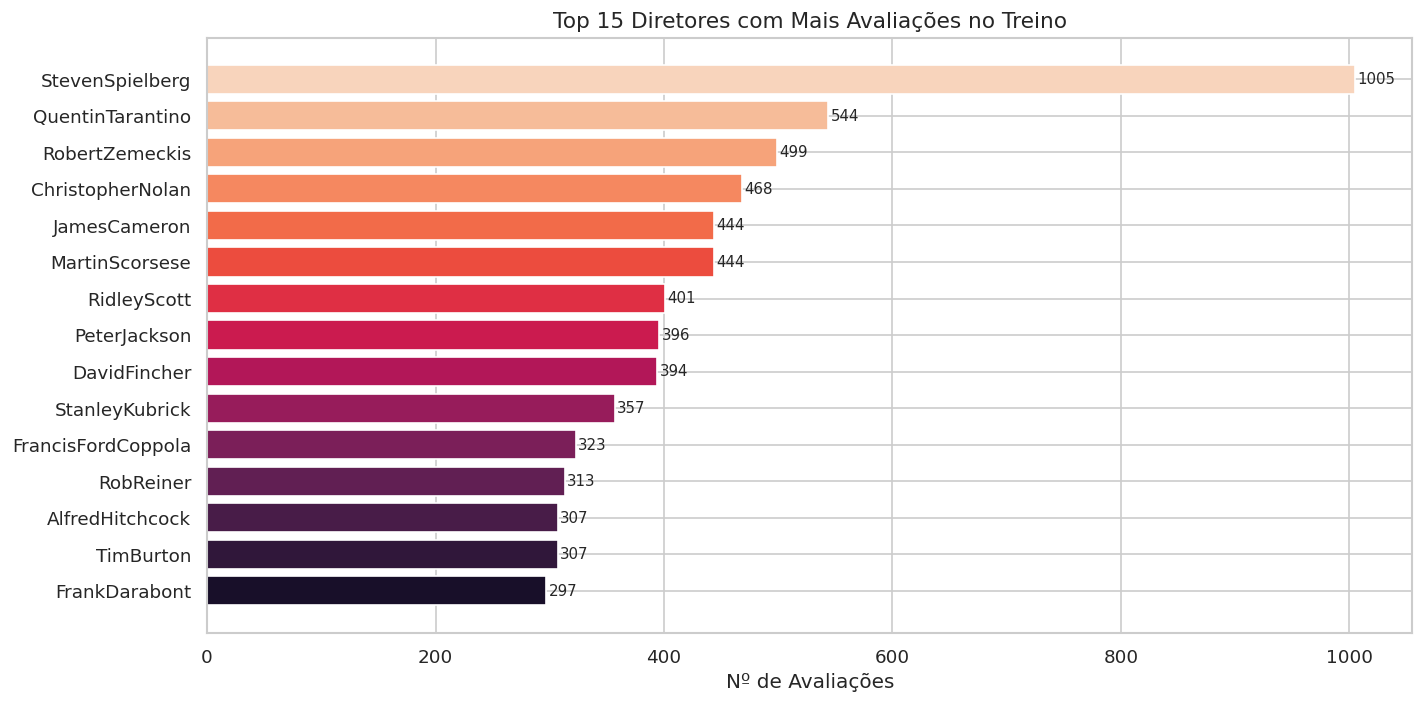

In [20]:
# 8.2 Diretores mais presentes no dataset de treino
dir_stats = (
    df.dropna(subset=['director'])
    .groupby('director')
    .agg(n_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .query('n_ratings >= 30')
    .sort_values('n_ratings', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(dir_stats.index[::-1], dir_stats['n_ratings'][::-1],
               color=sns.color_palette('rocket', len(dir_stats)))
ax.set_title('Top 15 Diretores com Mais Avaliações no Treino', fontsize=13)
ax.set_xlabel('Nº de Avaliações')
for bar, val in zip(bars, dir_stats['n_ratings'][::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Resumo Estatístico

In [21]:
print('=' * 50)
print('RESUMO DO DATASET DE TREINO')
print('=' * 50)
print(f"Total de avaliações     : {len(train):,}")
print(f"Usuários únicos         : {train['userId'].nunique():,}")
print(f"Filmes únicos           : {train['movieId'].nunique():,}")
print(f"Rating médio global     : {train['rating'].mean():.3f}")
print(f"Desvio padrão           : {train['rating'].std():.3f}")
print(f"Avaliações/usuário      : min={ratings_per_user.min()}, med={ratings_per_user.median():.0f}, max={ratings_per_user.max()}")
print(f"Avaliações/filme        : min={ratings_per_movie.min()}, med={ratings_per_movie.median():.0f}, max={ratings_per_movie.max()}")
print(f"Gênero mais frequente   : {genre_movie_count.idxmax()} ({genre_movie_count.max()} filmes)")
print(f"Gênero mais consumido   : {mean_user_genre.idxmax()} ({mean_user_genre.max():.2%} prop. média por usuário)")
print(f"Gênero mais bem avaliado: {genre_rating['avg_rating'].idxmax()} ({genre_rating['avg_rating'].max():.2f})")
print('=' * 50)

RESUMO DO DATASET DE TREINO
Total de avaliações     : 38,614
Usuários únicos         : 608
Filmes únicos           : 5,775
Rating médio global     : 4.359
Desvio padrão           : 0.431
Avaliações/usuário      : min=2, med=32, max=981
Avaliações/filme        : min=1, med=2, max=210
Gênero mais frequente   : Drama (4361 filmes)
Gênero mais consumido   : Drama (17.69% prop. média por usuário)
Gênero mais bem avaliado: War (4.43)
